# Lab 3: MCMC (part 2), Gibbs sampling

## Advanced Statistical Estimation, Centrale Lille

This lab is about Markov chain Monte Carlo (MCMC) sampling methods. The first exercise (Lab 2) implements a Metropolis-Hastings sampler and studies the influence of a few parameters. This second exercise implements a Gibbs sampler for a Bayesian linear regression model.

**Report by Ugo Roccamatisi.**


In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as ss

### Exercise - Bayesian LASSO

Consider the following hierarchical model, a Bayesian linear regression model:
\begin{align}
\sigma^2 & \sim \text{InverseGamma}(a_0, b_0) & \\
\tau_j & \sim \text{InverseGamma} \left(1, \frac{\lambda^2}{2} \right) \qquad & \forall~j \in {1, ..., p} \\
\beta_j | \tau_j, \sigma^2 & \sim \mathcal{N} \left( 0, \frac{\sigma^2}{\tau_j} \right) \qquad & \forall~j \in {1, ..., p} \\
y_i | \boldsymbol{x}_i, \boldsymbol{\beta}, \sigma^2 & \sim \mathcal{N}(\boldsymbol{\beta}^{\top} \mathbf{x}_i, \sigma^2) \qquad & \forall~i \in {1, ..., n} \\
\end{align}

where:
* $y_i \in \mathbb{R}$ is the variable to predict;
* $\mathbf{x}_i \in \mathbb{R}^p$ are the features;
* $\boldsymbol{\beta} \in \mathbb{R}^p$ is the regression vector;
* $\sigma^2$ is the noise variance;
* $\boldsymbol{\tau} \in \mathbb{R}^p$ is a latent variable of the model.

$\lambda$, $a_0$ and $b_0$ are assumed known and fixed.
  
This model is called the *Bayesian LASSO* ([Park and Casella (2008)](https://people.eecs.berkeley.edu/~jordan/courses/260-spring09/other-readings/park-casella.pdf)). As a reminder, the LASSO is linear regression with an $\ell_1$ penalty.

Given the data $\mathcal{D} = \{ (\mathbf{x}_1, y_1), ... (\mathbf{x}_n, y_n) \}$, the goal is to characterize the posterior distribution $p(\boldsymbol{\beta}, \boldsymbol{\tau}, \sigma^2 | \mathcal{D})$. It is not analytically tractable, so we sample from it with an MCMC algorithm, more precisely a [Gibbs sampler](https://en.wikipedia.org/wiki/Gibbs_sampling).

The conditional distributions of the model are:
\begin{align}
\boldsymbol{\beta} | \boldsymbol{\tau}, \sigma^2, \mathcal{D} \sim \mathcal{N}(\mathbf{A} \mathbf{X}^{\top} \mathbf{y}, \sigma^2 \mathbf{A}),
\end{align}
with $\mathbf{A} = (\mathbf{X}^{\top} \mathbf{X} + \mathbf{D}_{\tau})^{-1}$, where $\mathbf{D}_{\tau} = \text{diag}(\tau_1, ..., \tau_p)$.
\begin{align}
\tau_j | \boldsymbol{\beta}, \sigma^2, \mathcal{D} \sim \text{InverseGaussian}\left( \frac{\lambda \sigma}{\beta_j}, \lambda^2 \right),
\end{align}
("Inverse Gaussian" distribution: see [here](https://en.wikipedia.org/wiki/Inverse_Gaussian_distribution))
\begin{align}
\sigma^2 | \boldsymbol{\beta}, \boldsymbol{\tau}, \mathcal{D} \sim \text{InverseGamma}\left( a_0 + \frac{n+p}{2},~b_0 + \frac{1}{2} || \mathbf{y - X} \boldsymbol{\beta} ||^2_2 + \frac{1}{2} \boldsymbol{\beta}^{\top} \mathbf{D}_{\tau} \boldsymbol{\beta}  \right).
\end{align}

In [2]:
# Dataset

from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

X = X*np.sqrt(442) # Standardize, X is already centered
y = (y-np.mean(y))/np.std(y) # Zero-mean output, as no intercept in the model for simplicity

**Q1.** Write a function implementing Gibbs sampling for this model, taking as arguments:
* The data in matrix form $\mathbf{X}$ and $\mathbf{y}$;
* The number of samples after burn-in $N_g$;
* The burn-in length $N_b$;
* The model hyperparameters $a_0,~b_0,~\lambda$.

It returns $N_g$ samples from the posterior $p(\boldsymbol{\beta}, \boldsymbol{\tau}, \sigma^2 | \mathcal{D})$. The chain can be initialized by sampling from the prior.

Note:
* To sample from an inverse gamma (a,b) distribution, use `invgamma.rvs(a, loc=0, scale=b)`
* To sample from an inverse Gaussian (m,l) distribution, use `invgauss.rvs(m/l, loc=0, scale=l)`

In [3]:
def bayesian_lasso_gibbs(X,y,Ng,Nb,a0,b0,l,seed=42):
    """Gibbs sampler on (beta,tau,sigma²), with tau = local precision."""
    if min(Ng,Nb,a0,b0,l)<=0:raise ValueError('Positive arguments required')
    rng=np.random.default_rng(seed);n,p=X.shape
    beta=np.zeros(p);sigma2=ss.invgamma.rvs(a0,scale=b0,random_state=rng)
    tau=ss.invgamma.rvs(1,scale=l*l/2,size=p,random_state=rng)
    XtX=X.T@X;Xty=X.T@y
    betas=np.empty((Ng,p));taus=np.empty((Ng,p));variances=np.empty(Ng)
    for it in range(Nb+Ng):
        # beta | tau, sigma², y: multivariate normal; Cholesky for stability.
        precision=XtX+np.diag(tau)
        chol=np.linalg.cholesky(precision)
        mean=np.linalg.solve(chol.T,np.linalg.solve(chol,Xty))
        beta=mean+np.sqrt(sigma2)*np.linalg.solve(chol.T,rng.normal(size=p))
        # tau_j | beta, sigma²: inverse Gaussian, mu=lambda*sigma/|beta_j|.
        # beta_j=0 has zero probability in theory; clipping protects the computation.
        ig_mean=l*np.sqrt(sigma2)/np.maximum(np.abs(beta),1e-12)
        tau=ss.invgauss.rvs(mu=ig_mean/l**2,scale=l**2,random_state=rng)
        residual=y-X@beta
        shape=a0+(n+p)/2
        scale=b0+.5*(residual@residual+np.dot(tau,beta**2))
        sigma2=ss.invgamma.rvs(shape,scale=scale,random_state=rng)
        if it>=Nb:
            i=it-Nb;betas[i]=beta;taus[i]=tau;variances[i]=sigma2
    return betas,taus,variances

**Q2.** Run the MCMC chain with the following parameters: $N_g = 2000$, $N_b = 1000$, $a_0 = 1.5$, $b_0 = 1$, $\lambda = 10$.

* Show the *trace plots* of $\sigma^2$ and of a few $\beta_p$. Comment.
* For all $\boldsymbol{\beta}$ and $\sigma^2$, plot a histogram or KDE of the $N_g$ samples, with the MMSE estimate on the same plot. Finally, give the 95% credible interval.

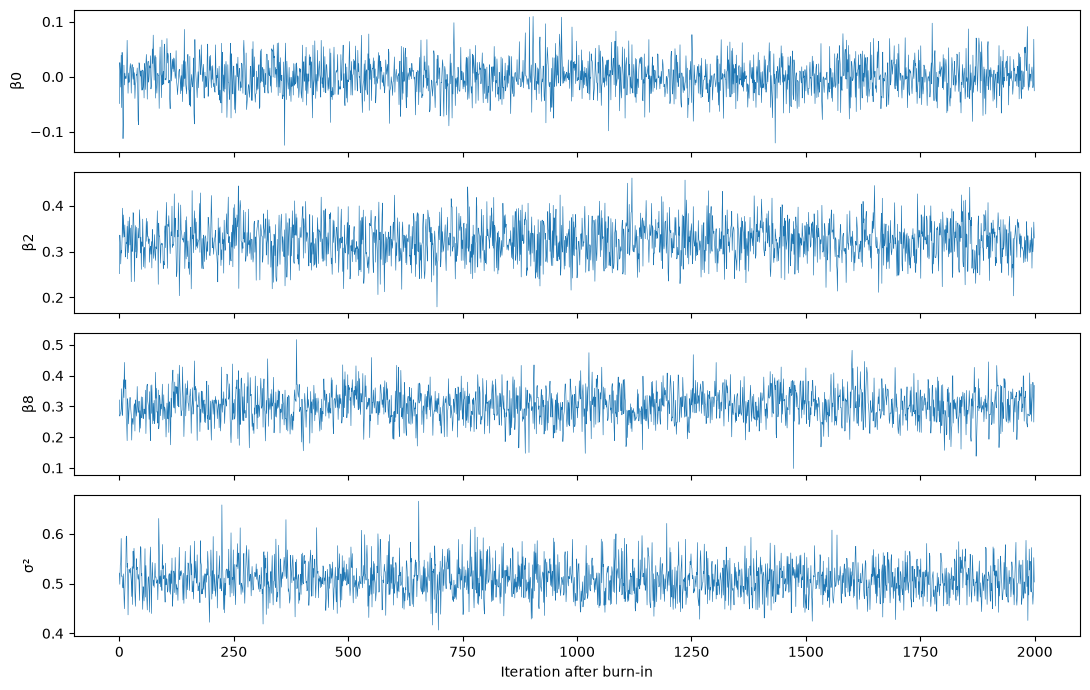

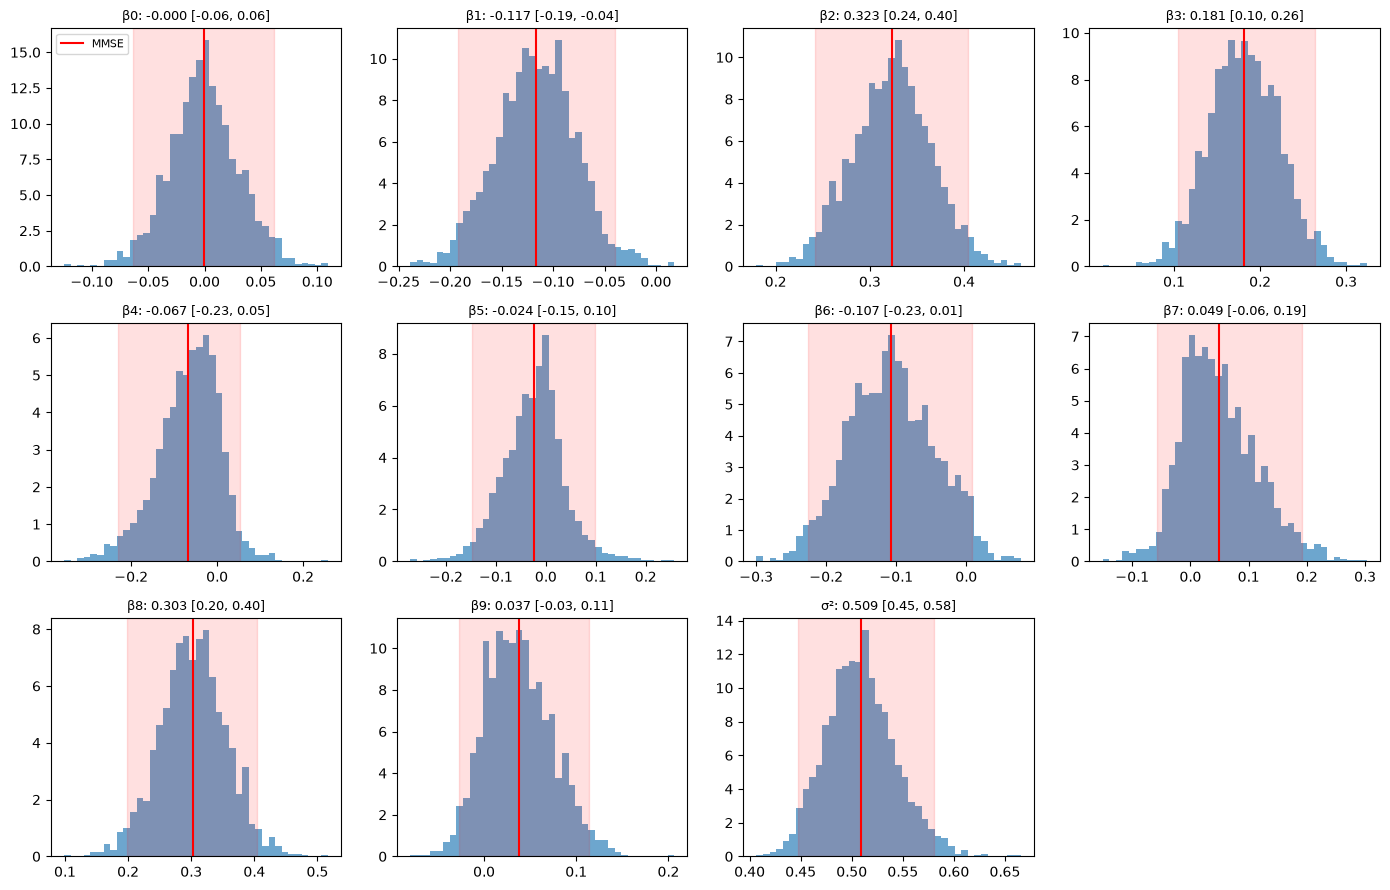

MMSE β: [-0.    -0.117  0.323  0.181 -0.067 -0.024 -0.107  0.049  0.303  0.037]
95% CrI of β (columns: lower, upper bound):
 [[-0.063  0.062]
 [-0.192 -0.04 ]
 [ 0.242  0.405]
 [ 0.104  0.263]
 [-0.232  0.054]
 [-0.147  0.099]
 [-0.226  0.008]
 [-0.057  0.191]
 [ 0.199  0.404]
 [-0.027  0.114]]
Mean σ² and CrI: 0.5087466239321572 [0.44748183 0.58094407]


In [4]:
Ng=2000;Nb=1000;a0=1.5;b0=1;l=10
betas,taus,variances=bayesian_lasso_gibbs(X,y,Ng,Nb,a0,b0,l)
fig,axes=plt.subplots(4,1,figsize=(11,7),sharex=True)
for ax,j in zip(axes[:3],[0,2,8]):ax.plot(betas[:,j],lw=.45);ax.set(ylabel=f'β{j}')
axes[3].plot(variances,lw=.45);axes[3].set(xlabel='Iteration after burn-in',ylabel='σ²');fig.tight_layout();plt.show()
fig,axes=plt.subplots(3,4,figsize=(14,9))
for j,ax in enumerate(axes.flat):
    if j>10:ax.axis('off');continue
    samples=betas[:,j] if j<10 else variances
    point=samples.mean();interval=np.quantile(samples,[.025,.975])
    ax.hist(samples,bins=40,density=True,alpha=.65)
    ax.axvline(point,c='red',label='MMSE');ax.axvspan(*interval,alpha=.12,color='red')
    ax.set_title(f'{"β"+str(j) if j<10 else "σ²"}: {point:.3f} [{interval[0]:.2f}, {interval[1]:.2f}]',fontsize=9)
axes.flat[0].legend(fontsize=8);fig.tight_layout();plt.show()
print('MMSE β:',np.round(betas.mean(axis=0),3))
print('95% CrI of β (columns: lower, upper bound):\n',np.round(np.quantile(betas,[.025,.975],axis=0).T,3))
print('Mean σ² and CrI:',variances.mean(),np.quantile(variances,[.025,.975]))

**Answer.** The trace plots visually check that the chain explores a stable region after burn-in; on their own they do not prove convergence. The red lines are the posterior means and the shaded intervals are the 95% credible quantiles. Correlated features can have individually uncertain coefficients.

**Q3.** Generate 1000 samples from the posterior predictive distribution at the new point $x_{\text{new}}$ (defined in the code) and plot a histogram or KDE. Comment.

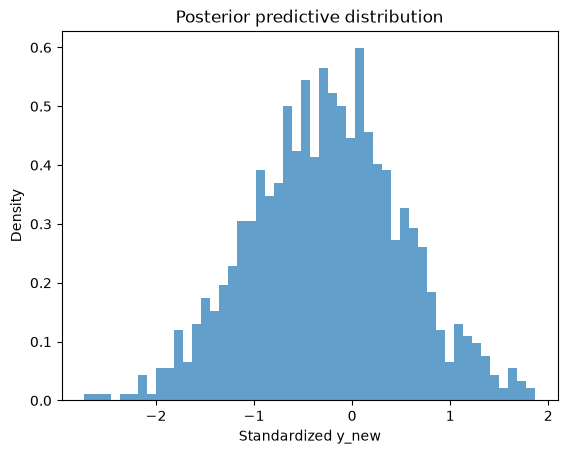

Predictive mean and 95% interval: -0.2554765717808776 [-1.74521752  1.26584627]


In [5]:
x_new=np.array([1.41145807,1.06548848,0.30006161,0.45984057,-0.52475728,-1.70643289,1.02259953,1.49710409,-1.25030999,0.84817082])
rng_pred=np.random.default_rng(123)
indices=rng_pred.choice(Ng,1000,replace=False)
# Each predictive draw also adds fresh N(0,sigma²) noise.
prediction=betas[indices]@x_new+rng_pred.normal(size=1000)*np.sqrt(variances[indices])
fig,ax=plt.subplots();ax.hist(prediction,bins=50,density=True,alpha=.7);ax.set(xlabel='Standardized y_new',ylabel='Density',title='Posterior predictive distribution');plt.show()
print('Predictive mean and 95% interval:',prediction.mean(),np.quantile(prediction,[.025,.975]))

**Answer.** The predictive distribution accounts for the uncertainty on β and σ² and adds the noise of a new observation. It is therefore wider than the distribution of x_newᵀβ alone.

**Result.** The predictive mean in standardized units is **−0.255**, with an empirical 95% predictive interval of **[−1.745, 1.266]**.


**Q4.** Study the influence of the parameter $\lambda$ on parameter inference (e.g. $\lambda = 1$ and $\lambda=100$). Comment.

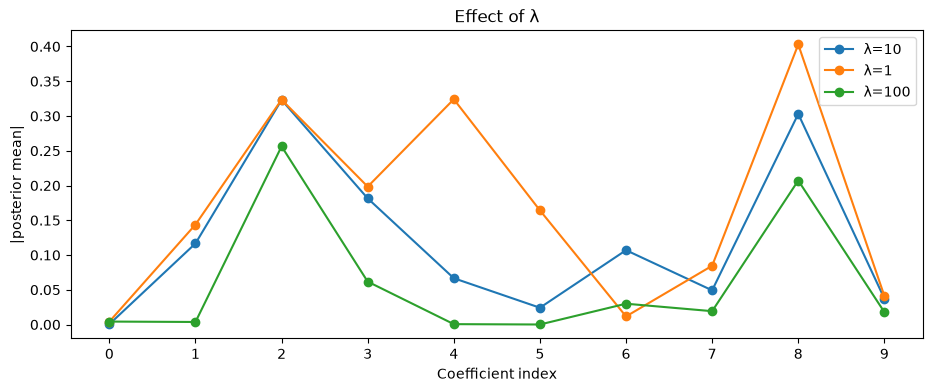

λ=10: ||E[β]||₁=1.209, mean σ²=0.509
λ=1: ||E[β]||₁=1.698, mean σ²=0.489
λ=100: ||E[β]||₁=0.601, mean σ²=0.681


In [6]:
fits={10:(betas,variances)}
for strength in (1,100):
    bs,ts,vs=bayesian_lasso_gibbs(X,y,Ng=2000,Nb=1000,a0=a0,b0=b0,l=strength,seed=42)
    fits[strength]=(bs,vs)
fig,ax=plt.subplots(figsize=(11,4))
for strength,(bs,vs) in fits.items():ax.plot(np.arange(X.shape[1]),np.abs(bs.mean(axis=0)),'o-',label=f'λ={strength}')
ax.set(xticks=np.arange(X.shape[1]),xlabel='Coefficient index',ylabel='|posterior mean|',title='Effect of λ');ax.legend();plt.show()
for strength,(bs,vs) in fits.items():
    print(f'λ={strength}: ||E[β]||₁={np.abs(bs.mean(axis=0)).sum():.3f}, mean σ²={vs.mean():.3f}')

**Answer.** In this parameterization, increasing λ concentrates the marginal prior of β near zero and favors stronger shrinkage. The |E[β]| curves and the printed L1 norms quantify this effect; correlated features can make some individual coefficients move the other way.

**Result.** The L1 norm of the mean β drops from 1.698 (λ=1) to 1.209 (λ=10), then to 0.601 (λ=100): overall shrinkage increases markedly.
